<a href="https://colab.research.google.com/github/The-Professor99/ML_Practice/blob/main/hands_on_learning/hands_on_ml_with_scikit-learn_Aurelien_textbook/Chap_18_Reinforcement_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Learning to Optimize Rewards
In Reinforcement Learning, a software agent makes observations and takes actions within an environment, and in return it receives rewards from the environment. Its objective is to learn to act in a way that will maximize its expected rewards over time. Positive rewards can be regarded as pleasure while negative rewards can be regarded as pain. The agent acts in the environment and learns by trial and error to maximize its pleasure and minimize its pain.
Sometimes, there may not be any positive rewards at all, for example, the agent may move around in a maze, getting a negative reward at every time step, so it had better find the exit as quickly as possible

### Policy Search
The algorithm a software agent uses to determine its actions is called its policy. The policy could be a neural network taking observations as inputs and outputting the action to take.

One way to explore a policy space is the brute force approach: try out many different values for the policy's parameters and pick the combination that performs best. However, when the policy space is too large(which is generally the case), finding a good set of parameters using this approach would be like searching for a needle in a gigantic haystack.

Another way to explore the policy space is to use genetic algorithms. For example, one could randomly create a first generation of 100 policies and try them out, then kill the 80 worst policies and make the 20 survivors produce 4 offspring each. An offspring is a copy of its parent plus some random variation. The surviving policies plus their offspring together constitute the second generation. One can continue to iterate through generations this way until he finds a good policy.

Yet another approach is to use optimization techniques, by evaluating the gradients of the rewards with regard to the policy parameters, then tweaking these parameters by following the gradients towards higher rewards. This approach is called policy gradients.

### OpenAI Gym
Read the intro here. Nice read.
Training is hard and slow in the real world, so you generally need a simulated environment atleast for bootstrap training. For example, PyBullet or MuJoCo for 3D physics simulation.


In [ ]:
!pip install gymnasium

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 7.2 MB/s eta 0:00:00


In [ ]:
import gymnasium as gym

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
def list_to_dict(np_array, names):
  assert len(np_array) == len(names), "np_array and names must \
  be same length"
  dict_obj = {}
  for item, name in zip(np_array, names):
    dict_obj[name] = item
  return dict_obj

In [ ]:
env = gym.make("CartPole-v1", render_mode="rgb_array")

In [ ]:
obs = env.reset(seed=42)

In [ ]:
list_to_dict(obs[0], ["position", "velocity",
                      "angle", "angular_velocity"])

{'position': 0.027395604,
 'velocity': -0.006112156,
 'angle': 0.035859793,
 'angular_velocity': 0.019736802}

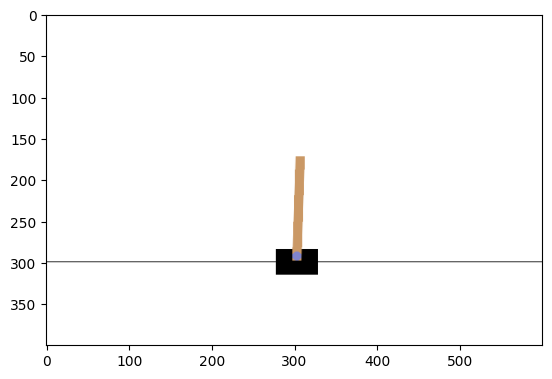

In [ ]:
img = env.render()
plt.imshow(img)

In [ ]:
gym.envs.registry.keys()

dict_keys(['CartPole-v0', 'CartPole-v1', 'MountainCar-v0', 'MountainCarContinuous-v0', 'Pendulum-v1', 'Acrobot-v1', 'phys2d/CartPole-v0', 'phys2d/CartPole-v1', 'phys2d/Pendulum-v0', 'LunarLander-v2', 'LunarLanderContinuous-v2', 'BipedalWalker-v3', 'BipedalWalkerHardcore-v3', 'CarRacing-v2', 'Blackjack-v1', 'FrozenLake-v1', 'FrozenLake8x8-v1', 'CliffWalking-v0', 'Taxi-v3', 'tabular/Blackjack-v0', 'tabular/CliffWalking-v0', 'Reacher-v2', 'Reacher-v4', 'Pusher-v2', 'Pusher-v4', 'InvertedPendulum-v2', 'InvertedPendulum-v4', 'InvertedDoublePendulum-v2', 'InvertedDoublePendulum-v4', 'HalfCheetah-v2', 'HalfCheetah-v3', 'HalfCheetah-v4', 'Hopper-v2', 'Hopper-v3', 'Hopper-v4', 'Swimmer-v2', 'Swimmer-v3', 'Swimmer-v4', 'Walker2d-v2', 'Walker2d-v3', 'Walker2d-v4', 'Ant-v2', 'Ant-v3', 'Ant-v4', 'Humanoid-v2', 'Humanoid-v3', 'Humanoid-v4', 'HumanoidStandup-v2', 'HumanoidStandup-v4', 'GymV21Environment-v0', 'GymV26Environment-v0'])

In [ ]:
env.action_space

Discrete(2)

In [ ]:
action = 1
obs, reward, terminated, truncated, info = env.step(action)


In [ ]:
env.close()

In [ ]:
def basic_policy(obs):
  angle = list_to_dict(obs[0] if type(obs) == tuple else obs,
   ["position", "velocity", "angle", "angular_velocity"])["angle"]
  return 0 if angle < 0 else 1

totals = []
for episode in range(500):
  episode_rewards = 0
  obs = env.reset(seed=episode)
  for set in range(200):
    action = basic_policy(obs)
    obs, reward, terminated, truncated, info = env.step(action)
    episode_rewards += reward
    if terminated or truncated:
      break
  totals.append(episode_rewards)

In [ ]:
np.mean(totals), np.std(totals), min(totals), max(totals)

(41.698, 8.389445512070509, 24.0, 63.0)

### Neural Network Policies

This neural network will take an observation as input, and it will output the action to be executed. More precisely, it will estimate a probability for each action, and then we will select an action randomly according to the estimated probabilities. In the current CartPole environment, there are just two possible actions(left or right), so we only need one output neuron. it will output the probability p of action 0(left) and of course the probability of action 1(right) will be 1-p. Eg, if it outputs 0.7, then we will pick action 0 with 70% probability, or action 1 with 30% probability.

But why are we picking a random action based on the probabilities given by the neural network rather than just picking the action with the highest score. This approach lets the agent find the right balance between exploring new actions and exploiting the actions that are known to work well. Here's an analogy: Suppose you go to a restaurant for the first time, and all the dishes loook equally apealling, so you randomly pcik one. If it turns out to be good, you can increase the probability that you'll order it next time, but you shouldn't increase that probability up to 100% else you will never try out the other dishes, some of which may be even better than the one you tried.

In this particular environment, the past actions and observations can safely be ignored, since each observation contains the environment's full state. If there were some hidden state, then you might need to consider past actions and observations as well. If there were some hidden state, then you might need to consider past actions and observations as well. Eg if the environment only revealed the position of the cart but not its velocity, you would have to consider not only the current observation but also the previous observation in order to estimate the current velocity.

In [ ]:
import tensorflow as tf
import matplotlib.animation
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rc('animation', html='jshtml')

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(5, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

Ok, so we now have a neural network policy that will take observations and output action probabilities but how do we train it?

### Evaluating Actions: The Credit Assignment Problem
If we knew what the best action was at each step, we could train the neural network as usual, by minimizing the cross entropy between the estimated probability distribution and the target probability distribution. It would just be regular supervised learning. However, in Reinforcement learning, the only guidance the agent gets is through rewards, and rewards are typically sparse and delayed. Eg, if the agent manages to balance the pole for 100 steps, how can it know which of the 100 actions it tookk were good and which of them were bad? All it knows is that the pole fell after the last action, but surely, this last action is not entirely responsible. This is called the credit assignment problem: when the agent gets a reward, it is hard for it to know which actions should get credited(or blamed) for it. Think of a dog that gets rewarded hours after it behaved well; will it understand what it is being rewarded for?

To tackle this problem, a common strategy is to evaluate an action based on the sum of all the rewards that come after it, usually applying a discount factor γ(gamma) at each step. This sum of discounted rewards is called the action's return.
Assuming in an environment, an agent decides to go right 3times in a row and gets +10 reward after the 1st step, 0 after the second step and finallly -50 after the 3rd step, assuming we use a discount factor γ = 0.8, the first action will have a return of (10 + (γ*0) + (γ^2 x -50)) = -22. If the discount factor is close to 0, then future rewards won't count for much compared to immediate rewards. Conversely, if the discount factor is close to 1, then rewards far into the future will count almost as much as immediate rewards. γ usually vary from 0.9 to 0.99, with a γ of 0.95, rewards 13steps into the future count roughly for half as much as immediate rewards since 0.95^13 ~ 0.5 while with a discount factor of 0.99, rewards 69 steps into the future count for half as much as immediate rewards.
In the cartpole environment, actions have fairly short term effects so choosing a γ of 0.95 seems reasonable.

It is also worth nothing that a good action may be followed by several bad actions that can cause the pole to fall quickly, resulting in the good action getting a low return, similarly, a good actor may sometimes star in a terrible movie. However, if we play the game enough times, on average, good actions will get a higher return than bad ones. We want to estimate how much better or worse an action is, compared to the other possible actions on average. This is called action advantage. For this, we must run many episodes and normalize all the action returns by subtracting the mean aand dividing by the standard deviation. After that, we can reasonable assume that actions with a negative advantage were bad while actions with a positive advantage were good.

Now that we have a way to evaluate each action, let's train our first agent using policy gradients.

### Policy Gradients(PG)
PG algorithms optimize the parameters of a policy by following the gradients toward higher rewards. The _Policy Gradients_ algorithm tackles the credits assignment problem by first playing multiple episodes, then making the actions near positive rewards slightly more likely, while actions near negative rewards are made slightly less likely. First we play, then we go back and think about what we did.

Check the book for some important explanation.

Let's use keras to implement this algorithm(specified in the book). We will train the neural network policy we built earlier so that it learns to balance the pole on the cart. first, we need a function that will play one step. We will pretend for now that whatever action it takes is the right one so that we can compute the loss and its gradients. These gradients will just be saved for a while, and we will modify them later depending on how good or bad the action turned out to be.

In [ ]:
def play_one_step(env, obs, model, loss_fn):
    with tf.GradientTape() as tape:
        left_proba = model(obs[np.newaxis])
        action = (tf.random.uniform([1, 1]) > left_proba)
        y_target = tf.constant([[1.]]) - tf.cast(action, tf.float32)
        loss = tf.reduce_mean(loss_fn(y_target, left_proba))

    grads = tape.gradient(loss, model.trainable_variables)
    obs, reward, done, truncated, info = env.step(int(action))
    return obs, reward, done, truncated, grads

Check the book incase you forget what the fxn above does.

Now lets create another fxn that will rely on the play_one_step fxn to play multiple episodes, returning all the rewards and gradients for each episode and each step:

In [ ]:
def play_multiple_episodes(env, n_episodes, n_max_steps, model, loss_fn):
    all_rewards = []
    all_grads = []
    for episode in range(n_episodes):
        current_rewards = []
        current_grads = []
        obs, info = env.reset()
        for step in range(n_max_steps):
            obs, reward, done, truncated, grads = play_one_step(
                env, obs, model, loss_fn)
            current_rewards.append(reward)
            current_grads.append(grads)
            if done or truncated:
                break

        all_rewards.append(current_rewards)
        all_grads.append(current_grads)

    return all_rewards, all_grads

The algorithm will use the play_multiple episodes fxn to play the game several times, then it will go back and look at all the rewards, discount them, and normalize them. To do that, we need a fxn to compute the sum of future discounted rewards at each step, and a second fxn to normalize all these discounted rewards across many episodes by subtracting the mean and dividing by the standard deviation:

In [ ]:
def discount_rewards(rewards, discount_factor):
    discounted = np.array(rewards)
    for step in range(len(rewards) - 2, -1, -1):
        discounted[step] += discounted[step + 1] * discount_factor
    return discounted

def discount_and_normalize_rewards(all_rewards, discount_factor):
    all_discounted_rewards = [discount_rewards(rewards, discount_factor)
                              for rewards in all_rewards]
    flat_rewards = np.concatenate(all_discounted_rewards)
    reward_mean = flat_rewards.mean()
    reward_std = flat_rewards.std()
    return [(discounted_rewards - reward_mean) / reward_std
            for discounted_rewards in all_discounted_rewards]

In [ ]:
# extra code – this cell displays an animation of one episode

def update_scene(num, frames, patch):
    patch.set_data(frames[num])
    return patch,

def plot_animation(frames, repeat=False, interval=40):
    fig = plt.figure()
    patch = plt.imshow(frames[0])
    plt.axis('off')
    anim = matplotlib.animation.FuncAnimation(
        fig, update_scene, fargs=(frames, patch),
        frames=len(frames), repeat=repeat, interval=interval)
    plt.close()
    return anim

def show_one_episode(policy, n_max_steps=200, seed=42):
    frames = []
    env = gym.make("CartPole-v1", render_mode="rgb_array")
    np.random.seed(seed)
    obs, info = env.reset(seed=seed)
    for step in range(n_max_steps):
        frames.append(env.render())
        action = policy(obs)
        obs, reward, done, truncated, info = env.step(action)
        if done or truncated:
            break
    env.close()
    return plot_animation(frames)


In [ ]:

def pg_policy(obs):
    left_proba = model.predict(obs[np.newaxis], verbose=0)
    return int(np.random.rand() > left_proba)



In [ ]:
n_iterations = 150
n_episodes_per_update = 10
n_max_steps = 200
discount_factor = 0.95

In [ ]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(5, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

obs, info = env.reset(seed=42)

In [ ]:
optimizer = tf.keras.optimizers.Nadam(learning_rate=0.01)
loss_fn = tf.keras.losses.binary_crossentropy

In [ ]:
for iteration in range(n_iterations):
    all_rewards, all_grads = play_multiple_episodes(
        env, n_episodes_per_update, n_max_steps, model, loss_fn)

    # extra code – displays some debug info during training
    total_rewards = sum(map(sum, all_rewards))
    print(f"\rIteration: {iteration + 1}/{n_iterations},"
          f" mean rewards: {total_rewards / n_episodes_per_update:.1f}", end="")

    all_final_rewards = discount_and_normalize_rewards(all_rewards,
                                                       discount_factor)
    all_mean_grads = []
    for var_index in range(len(model.trainable_variables)):
        mean_grads = tf.reduce_mean(
            [final_reward * all_grads[episode_index][step][var_index]
             for episode_index, final_rewards in enumerate(all_final_rewards)
                 for step, final_reward in enumerate(final_rewards)], axis=0)
        all_mean_grads.append(mean_grads)

    optimizer.apply_gradients(zip(all_mean_grads, model.trainable_variables))

Iteration: 150/150, mean rewards: 153.6

In [ ]:
np.random.seed(42)
show_one_episode(pg_policy)

Researchers try to find algorithms that work well even when the
agent initially knows nothing about the environment. However,
unless you are writing a paper, you should not hesitate to inject
prior knowledge into the agent, as it will speed up training dramat‐
ically. For example, since you know that the pole should be as verti‐
cal as possible, you could add negative rewards proportional to the
pole’s angle. This will make the rewards much less sparse and speed
up training. Also, if you already have a reasonably good policy (e.g.,
hardcoded), you may want to train the neural network to imitate it
before using policy gradients to improve it.




### Markov Decision Processes
Markov chains are stochastic processes with no memory. the processes have a fixed number of states, and randomly evolves from one state to another at each step. The probability for it to evolve from a state s to a state s' is fixed and it depends only on the pair(s, s'), not on past states(hence the system has no memory)

Check this part again!!!  especially the Value Iteration Algorithm part.

### Temporal Difference Learning
Reinforcement Learning problems with discrete actions can often be modeled as Markow decision processes, but the agent initially has no idea what the transition probabilities are, and it does not know what the rewards are going to be either. It must experience each state and each transition atleast once to know the rewards, and it must experience them multiple times if it is to have a reasonable estimate of the transition probabilities.
The Temporal Difference Learning(TD Learning) algorithm is very similar to the value iteration algorithm but tweaked to take into account the fact that the agent has only partial knowledge of the MDP. In general, we assume that the agent initially knows only the possible states and actions, and nothing more.The agent uses an exploration policy to explore the MDP, and as it progresses, the TD Learning algorithm updates the estimates of the state values based on the transitions and rewards that are actually observed.

### Q-Learning
This is an adaptation of the Q-Value Iteration algorithm to the situation where the transition probabilities and the rewards are initially unknown. Q-Learning works by watching an agent play(eg randomly) and gradually improving its estimates of the Q-values. Once it has accurate Q value estimates(or close enough), then the optimal policy is just choosing the action that has the highest Q value(greedy policy).

For each state-action pair(s, a), this algorithm keeps track of a running average of rewards the agent gets upon leaving the state s with action a, plus the sum of discounted future rewards it expects to get. To estimate this sum, we take the maximum of the Q-Value estimates for the next state s' since we assume that the target policy would act optimally from then on.

Let's implement the Q-Learning algorithm, first we need to make an agent explore the environment. For this, we need a step fxn so that the agent can execute one action and get the resulting state and reward.


In [ ]:
def step(state, action):
    probas = transition_probabilities[state][action]
    next_state = np.random.choice([0, 1, 2], p=probas)
    reward = rewards[state][action][next_state]
    return next_state, reward

Lets then implement the agent's exploration policy, since the state space is pretty small, a small random policy will be sufficient. If the algorithm is ran long enough, the agent will very state many times and it will also try every possible action may times

In [ ]:
def exploration_policy(state):
    return np.random.choice(possible_actions[state])

In [ ]:
# Q Learning algorithm
alpha0 = 0.05 #initial learning rate
decay = 0.005 # learning rate decay
gamma = 0.90 # discount factor
state = 0 # initial state
for iteration in range(10_000):
    action = exploration_policy(state)
    next_state, reward = step(state,action)
    next_value = Q_values[next_state].max() # greedy policy at next step
    alpha = alpha0 / (1 + iteration * decay)
    Q_values[state, action] *= 1 - alpha
    Q_values[state, action] += alpha * (reward + gamma * next_value)
    state = next_value

QLearning algorithm is called off-policy algorithm because the policy being trained is not necessarily the one used during training. Policy gradients algorithm is an on policy algorithm

### Exploration Policies
QLearning can work only if the exploration policy explores the MDP thoroughly enough. Although a purely random policy is guaranteed to eventually visit every state and every transition many times, it may take an extremely long time to do so. therefore, a better option is to use the e-greedy policy(e is epsilon): at each step, it acts randomly with probablity e or greedily with probability 1-e. The advantage of e-greedy policy(compared to a completely random policy) is that it will spend more and more time exploring the interesting parts of the environment, as the Q-value estimates get better and better, while still spending some time visiting unknown regions of the MDP.

Alternatively, rather than relying only on chance for exploration, another approach is to encourage the exploration policy to try actions that it has not tried much before.



Check out the book for more.

Reinforcement Learning, Industrial Applications of Intelligent Agents by Phil Winder (O’Reilly, 2020).
